# Segmentazione di cavi per il dataset TTPLA utilizzando Masked-attention Mask Transformer 

Masked-attention Mask Transformer (Mask2Former) è un'architettura in grado di affrontare qualsiasi attività di segmentaizone delle immagini(panottica, di istanza o semantica). Oltre a ridurre lo sforzo di ricerca, supera le migliori architetture, in particolare mask2former ha ottenuto per la segmentazione delle istanze 50,1 AP su COCO.(https://arxiv.org/abs/2112.01527)


L'obiettivo di questo progetto è fare Istance Segmentation di cavi. Per affrontare questo task è stato scelto il framework Mask2Former analizzando il comportamento con diversi tipi di backbone:ResNet-50,ResNet-101,Swin-S. La struttura di mask2former si divide in tre componenti: 
- un backbone per l'estrazione delle feature
- un pixel decoder che genera embedding per pixel
- un trasformer decoder che elabora le object queries per predire maschere binarie

## ResNet-50 e ResNet-101
- architettura: utilizza una struttura convoluzionale
- ResNet-50 funge da baseline di confronto

## Swin transformer
- Architettura: basata su blocchi transformer che operano su finestre gerarchiche (shifted windows). 


Approcci utilizzati:
- data augmentation
- implementazione della ThinCableLoss basata su clDice
- estensione dell'input del modello da 3 canali RGB a 5 canli RGB + X + Y
- implementazione di una testa di regressione per la stima dell'orientamento locale dei cavi basata su PCA delle maschere di segmentazione, permettendo al modello di predire non solo dove sia il cavo ma anche la sua inclinazione.

## Workflow
- HPO (optuna): ricerca dei migliori iperparametri per massimizzare mAP
- Addestramento
- Fine tuning: addestramento a risoluzione 1408x1408

In [ ]:
import os
import json
DATA_ROOT = "/kaggle/input/datasetttpla/dataset"
PROJECT_ROOT = "/kaggle/input/ProgettoCV25_26"
TRAIN_JSON = os.path.join(DATA_ROOT, "train/train.json")
TEST_JSON  = os.path.join(DATA_ROOT, "test/test.json")
IMAGES_DIR = os.path.join(DATA_ROOT, "train")
print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_JSON:", TRAIN_JSON)
print("TEST_JSON:", TEST_JSON)

# Caricamento dei file JSON
with open(TRAIN_JSON, "r") as f:
    train_data = json.load(f)

with open(TEST_JSON, "r") as f:
    test_data = json.load(f)

# Estrazione delle liste principali (COCO-style)
train_images = train_data.get("images", [])
train_annotations = train_data.get("annotations", [])
train_categories = train_data.get("categories", [])

test_images = test_data.get("images", [])
test_annotations = test_data.get("annotations", [])
test_categories = test_data.get("categories", [])

print("== TRAIN ==")
print("Numero immagini:", len(train_images))
print("Numero annotazioni:", len(train_annotations))
print("Numero categorie:", len(train_categories))

print("\n== TEST ==")
print("Numero immagini:", len(test_images))
print("Numero annotazioni:", len(test_annotations))
print("Numero categorie:", len(test_categories))

print("\nCategorie nel train:")
for cat in train_categories:
    print(cat)

# Visualizziamo una annotazione di esempio per capire la struttura
print("\nEsempio annotazione train:")
if len(train_annotations) > 0:
    example_ann = train_annotations[0]
    for k, v in example_ann.items():
        print(f"{k}: {v}")


DATA_ROOT: ./dataset
TRAIN_JSON: ./dataset\train/train.json
TEST_JSON: ./dataset\test/test.json
== TRAIN ==
Numero immagini: 842
Numero annotazioni: 6775
Numero categorie: 1

== TEST ==
Numero immagini: 400
Numero annotazioni: 3328
Numero categorie: 1

Categorie nel train:
{'supercategory': 'cable', 'id': 0, 'name': 'cable'}

Esempio annotazione train:
segmentation: [[0.0, 125.74074074074075, 142.93323863636363, 106.79713804713805, 309.0672348484849, 84.70117845117846, 470.138134057971, 64.87117552334944, 612.0086050724638, 45.14492753623188, 699.8177083333334, 32.407407407407405, 699.8177083333334, 44.07407407407407, 589.0240036231884, 57.826086956521735, 430.87121212121207, 80.28198653198653, 222.89299242424244, 107.53367003367003, 95.703125, 123.73737373737374, 0.8285984848484849, 134.78535353535355]]
iscrowd: 0
area: 7395.351122607652
image_id: 0
bbox: [0.0, 32.0, 699.0, 102.0]
category_id: 0
id: 1
polar_coordinates: [{'diagonal_type': 'bottom_left_to_top_right', 'rho': 132.5957259

In [6]:
from collections import defaultdict

# Dizionari: image_id -> info immagine
train_imgs_by_id = {img["id"]: img for img in train_images}
test_imgs_by_id = {img["id"]: img for img in test_images}

# Dizionari: image_id -> lista di annotazioni
train_anns_by_img = defaultdict(list)
for ann in train_annotations:
    train_anns_by_img[ann["image_id"]].append(ann)

test_anns_by_img = defaultdict(list)
for ann in test_annotations:
    test_anns_by_img[ann["image_id"]].append(ann)

print("Esempio: numero di annotazioni per la prima immagine train:")

if len(train_images) > 0:
    first_img_id = train_images[0]["id"]
    print("image_id:", first_img_id)
    print("file_name:", train_images[0]["file_name"])
    print("num_annotazioni:", len(train_anns_by_img[first_img_id]))

Esempio: numero di annotazioni per la prima immagine train:
image_id: 0
file_name: 57_01156.jpg
num_annotazioni: 4


## Analisi esplorativa del dataset (EDA)

Obiettivi di questa sezione:

- Visualizzare alcune immagini con:
  - maschere dei cavi,
  - bounding box,
  - retta corrispondente alle `polar_coordinates`.
- Calcolare alcune statistiche di base:
  - numero di cavi per immagine,
  - distribuzione delle aree delle maschere,
  - distribuzione delle lunghezze approssimative dei cavi,
  - distribuzione degli angoli.



Numero annotazioni per questa immagine: 3


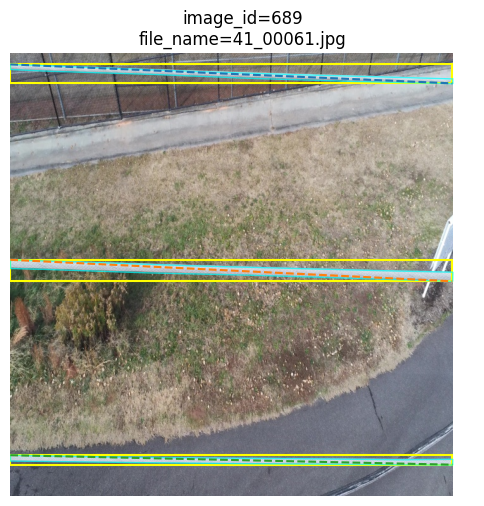

In [7]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Polygon, Rectangle

def plot_image_with_annotations(image_info, anns, images_dir, show_line=True):

    img_path = os.path.join(images_dir, image_info["file_name"])
    img = Image.open(img_path).convert("RGB")
    width, height = img.size

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.set_title(f'image_id={image_info["id"]}\nfile_name={image_info["file_name"]}')
    ax.axis("off")

    for ann in anns:
        # Bounding box: formato [x, y, w, h]
        bbox = ann.get("bbox", None)
        if bbox is not None:
            x, y, w, h = bbox
            rect = Rectangle(
                (x, y),
                w,
                h,
                linewidth=1.5,
                edgecolor="yellow",
                facecolor="none",
            )
            ax.add_patch(rect)

        # Maschera poligonale (COCO polygon)
        seg = ann.get("segmentation", None)
        if seg is not None and isinstance(seg, list) and len(seg) > 0:
            # Potrebbero esserci più poligoni
            for poly in seg:
                if not isinstance(poly, list) or len(poly) < 6:
                    continue
                xs = poly[0::2]
                ys = poly[1::2]
                poly_patch = Polygon(
                    np.stack([xs, ys], axis=1),
                    linewidth=1,
                    edgecolor="cyan",
                    facecolor="none",
                    alpha=0.7,
                )
                ax.add_patch(poly_patch)

        # Linea dai punti in polar_coordinates 
        if show_line:
            polar_list = ann.get("polar_coordinates", None)
            if polar_list is not None:
                if isinstance(polar_list, list) and len(polar_list) > 0:
                    polar = polar_list[0]
                else:
                    polar = None

                if polar is not None:
                    start = polar.get("start_point", None)
                    end = polar.get("end_point", None)
                    if start is not None and end is not None:
                        x1, y1 = start
                        x2, y2 = end
                        ax.plot([x1, x2], [y1, y2], linestyle="--", linewidth=1.5)

    plt.show()


# Test rapido su una immagine casuale del train
if len(train_images) > 0:
    random_img_info = random.choice(train_images)
    img_id = random_img_info["id"]
    anns = train_anns_by_img[img_id]
    print("Numero annotazioni per questa immagine:", len(anns))
    plot_image_with_annotations(random_img_info, anns, IMAGES_DIR)



In [ ]:
import numpy as np
from collections import Counter

def analyze_annotations(annotations, images, title="DATASET"):
    if not annotations:
        print(f"Nessuna annotazione trovata per {title}")
        return

    
    areas = [ann['area'] for ann in annotations]
    bboxes = [ann['bbox'] for ann in annotations] # [x, y, width, height]
    
    widths = [b[2] for b in bboxes]
    heights = [b[3] for b in bboxes]
    aspect_ratios = [b[2] / b[3] if b[3] != 0 else 0 for b in bboxes]
    
    
    img_ids = [ann['image_id'] for ann in annotations]
    obj_per_img = Counter(img_ids).values()

    
    stats = {
        "Area Min": np.min(areas),
        "Area Max": np.max(areas),
        "Area Media": np.mean(areas),
        "Area Mediana": np.median(areas),
        "Larghezza Max (px)": np.max(widths),
        "Altezza Max (px)": np.max(heights),
        "Aspect Ratio Medio (W/H)": np.mean(aspect_ratios),
        "Oggetti per immagine (Media)": np.mean(list(obj_per_img)),
        "Oggetti per immagine (Max)": np.max(list(obj_per_img))
    }

    print(f"\n--- STATISTICHE APPROFONDITE: {title} ---")
    for key, value in stats.items():
        print(f"{key:30}: {value:.2f}")

    
    small_objects = sum(1 for a in areas if a < 32**2)
    print(f"Oggetti 'Small' (area < 1024px²): {small_objects} ({small_objects/len(areas)*100:.1f}%)")


analyze_annotations(train_annotations, train_images, "TRAIN SET")




--- STATISTICHE APPROFONDITE: TRAIN SET ---
Area Min                      : 0.71
Area Max                      : 48450.90
Area Media                    : 1289.26
Area Mediana                  : 589.53
Larghezza Max (px)            : 700.00
Altezza Max (px)              : 701.00
Aspect Ratio Medio (W/H)      : 2.99
Oggetti per immagine (Media)  : 8.11
Oggetti per immagine (Max)    : 46.00
Oggetti 'Small' (area < 1024px²): 4313 (63.7%)


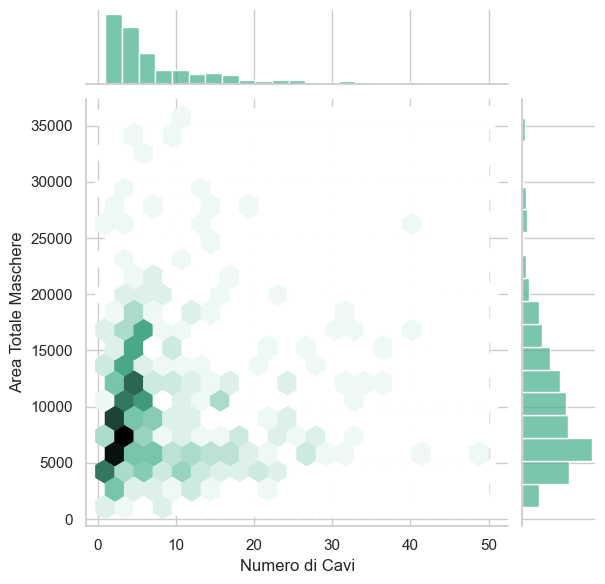

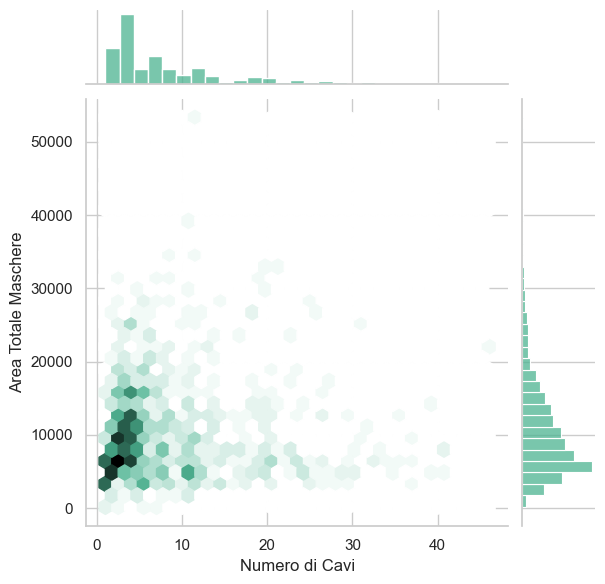

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
def plot_joint_density(annotations):
    img_stats = {}
    for ann in annotations:
        img_id = ann['image_id']
        if img_id not in img_stats: img_stats[img_id] = {'n': 0, 'a': 0}
        img_stats[img_id]['n'] += 1
        img_stats[img_id]['a'] += ann['area']
    
    df = pd.DataFrame.from_dict(img_stats, orient='index')
    
    g = sns.jointplot(data=df, x="n", y="a", kind="hex", color="#4CB391")
    g.set_axis_labels("Numero di Cavi", "Area Totale Maschere", fontsize=12)
    plt.show()

plot_joint_density(test_annotations)
plot_joint_density(train_annotations)

## Creazione dello split Train / Validation

In questa sezione partiamo dal file **`train.json`** originale (842 immagini) e lo
spezziamo in:

- `train_split.json` → usato per il **training** del modello
- `val_split.json`   → usato per la **validazione** (tuning iperparametri, scelta checkpoint)

Caratteristiche dello split:

Qui facciamo lo split **per gruppo**, dove il gruppo è definito dal **prefisso
del file_name prima di "_"** (es. `105_2745.jpg` → gruppo `105`).

- Tutte le immagini dello stesso gruppo vanno **tutte in train** oppure **tutte in val**.
- Proporzione: 80% gruppi train / 20% gruppi val (random con seed fisso).
- Generiamo due nuovi file:
  - `train_group_split.json`
  - `val_group_split.json`

In [4]:
import collections
import random

full_images = train_images
full_annotations = train_annotations
full_categories = train_categories

print("Numero totale immagini:", len(full_images))

def get_prefix(file_name: str) -> str:
    return file_name.split("_")[0]

group_to_image_ids = collections.defaultdict(list)
group_to_images = collections.defaultdict(list)

for img in full_images:
    fname = img["file_name"]          
    prefix = get_prefix(fname)
    group_to_image_ids[prefix].append(img["id"])
    group_to_images[prefix].append(img)

num_groups = len(group_to_image_ids)
print("Numero di gruppi (prefissi) trovati:", num_groups)

# Statistiche sul numero di immagini per gruppo
group_sizes = [len(ids) for ids in group_to_image_ids.values()]
print("Dimensione gruppi (num immagini):")
print("  Min:", min(group_sizes))
print("  Max:", max(group_sizes))
print("  Media:", sum(group_sizes) / len(group_sizes))

# Mostriamo qualche esempio di gruppo
print("\nEsempi di gruppi (prefisso -> num immagini, alcuni file_name):")
for i, (prefix, imgs) in enumerate(group_to_images.items()):
    print(f"  Prefisso {prefix}: {len(imgs)} immagini. Esempi:", [im["file_name"] for im in imgs[:3]])
    if i >= 5:  # mostriamo solo i primi 6 gruppi
        break


Numero totale immagini: 842
Numero di gruppi (prefissi) trovati: 82
Dimensione gruppi (num immagini):
  Min: 1
  Max: 54
  Media: 10.268292682926829

Esempi di gruppi (prefisso -> num immagini, alcuni file_name):
  Prefisso 57: 31 immagini. Esempi: ['57_01156.jpg', '57_00481.jpg', '57_00391.jpg']
  Prefisso 27: 19 immagini. Esempi: ['27_00394.jpg', '27_01456.jpg', '27_00907.jpg']
  Prefisso 59: 25 immagini. Esempi: ['59_00461.jpg', '59_01361.jpg', '59_00551.jpg']
  Prefisso 34: 20 immagini. Esempi: ['34_2295.jpg', '34_990.jpg', '34_1395.jpg']
  Prefisso 58: 19 immagini. Esempi: ['58_00921.jpg', '58_00831.jpg', '58_00956.jpg']
  Prefisso 52: 19 immagini. Esempi: ['52_00486.jpg', '52_00981.jpg', '52_00936.jpg']


In [5]:
# Lista dei prefissi (gruppi)
all_groups = list(group_to_image_ids.keys())
print("Totale gruppi:", len(all_groups))

# Shuffle con lo stesso seed per riproducibilità
GROUP_VAL_RATIO = 0.2
RANDOM_SEED_GROUP = 42

random.seed(RANDOM_SEED_GROUP)
random.shuffle(all_groups)

num_groups_total = len(all_groups)
num_groups_val = int(num_groups_total * GROUP_VAL_RATIO)
num_groups_train = num_groups_total - num_groups_val

val_groups = set(all_groups[:num_groups_val])
train_groups = set(all_groups[num_groups_val:])

print(f"\nSplit gruppi 80/20 con seed={RANDOM_SEED_GROUP}:")
print("  Gruppi train:", len(train_groups))
print("  Gruppi val:  ", len(val_groups))

# Controllo che non ci siano gruppi in comune
intersection_groups = train_groups.intersection(val_groups)
print("  Gruppi in comune tra train e val:", len(intersection_groups))
assert len(intersection_groups) == 0, "Errore: qualche gruppo è presente sia in train che in val!"


Totale gruppi: 82

Split gruppi 80/20 con seed=42:
  Gruppi train: 66
  Gruppi val:   16
  Gruppi in comune tra train e val: 0


In [ ]:

train_ids_group = set()
val_ids_group = set()

for prefix, img_ids in group_to_image_ids.items():
    if prefix in train_groups:
        train_ids_group.update(img_ids)
    elif prefix in val_groups:
        val_ids_group.update(img_ids)

print("Immagini totali (controllo):", len(full_images))
print("Immagini train (group split):", len(train_ids_group))
print("Immagini val   (group split):", len(val_ids_group))

# Controllo che non ci siano image_id in comune tra i due split
intersection_ids_group = train_ids_group.intersection(val_ids_group)
print("Image_id in comune tra train e val (group split):", len(intersection_ids_group))
assert len(intersection_ids_group) == 0, "Errore: qualche image_id è in entrambi gli split!"

# Ora costruiamo le liste images/annotations per ciascuno
train_images_group = [img for img in full_images if img["id"] in train_ids_group]
val_images_group   = [img for img in full_images if img["id"] in val_ids_group]

train_annotations_group = [ann for ann in full_annotations if ann["image_id"] in train_ids_group]
val_annotations_group   = [ann for ann in full_annotations if ann["image_id"] in val_ids_group]

print("\n== TRAIN GROUP SPLIT ==")
print("  Immagini:", len(train_images_group))
print("  Annotazioni:", len(train_annotations_group))

print("\n== VAL GROUP SPLIT ==")
print("  Immagini:", len(val_images_group))
print("  Annotazioni:", len(val_annotations_group))


train_group_split_data = {
    "images": train_images_group,
    "annotations": train_annotations_group,
    "categories": full_categories,
}

val_group_split_data = {
    "images": val_images_group,
    "annotations": val_annotations_group,
    "categories": full_categories,
}

TRAIN_GROUP_SPLIT_JSON = os.path.join(DATA_ROOT, "train_group_split.json")
VAL_GROUP_SPLIT_JSON   = os.path.join(DATA_ROOT, "val_group_split.json")

with open(TRAIN_GROUP_SPLIT_JSON, "w") as f:
    json.dump(train_group_split_data, f)

with open(VAL_GROUP_SPLIT_JSON, "w") as f:
    json.dump(val_group_split_data, f)

print("Salvato:", TRAIN_GROUP_SPLIT_JSON)
print("Salvato:", VAL_GROUP_SPLIT_JSON)

Immagini totali (controllo): 842
Immagini train (group split): 687
Immagini val   (group split): 155
Image_id in comune tra train e val (group split): 0

== TRAIN GROUP SPLIT ==
  Immagini: 687
  Annotazioni: 5559

== VAL GROUP SPLIT ==
  Immagini: 155
  Annotazioni: 1216
Salvato: ./dataset\train_group_split.json
Salvato: ./dataset\val_group_split.json


In [8]:
# statistiche group split
from collections import defaultdict
import numpy as np

def stats_split_group(images_split, annotations_split, split_name="train_group"):
    anns_by_img = defaultdict(list)
    for ann in annotations_split:
        anns_by_img[ann["image_id"]].append(ann)

    num_anns_per_img = [len(anns_by_img[img["id"]]) for img in images_split]

    print(f"\nStatistiche split: {split_name}")
    print("  Immagini:", len(images_split))
    print("  Annotazioni:", len(annotations_split))
    if num_anns_per_img:
        print("  Cavi per immagine - min:", np.min(num_anns_per_img))
        print("  Cavi per immagine - max:", np.max(num_anns_per_img))
        print("  Cavi per immagine - media:", np.mean(num_anns_per_img))

stats_split_group(train_images_group, train_annotations_group, "train_group_split")
stats_split_group(val_images_group, val_annotations_group, "val_group_split")


Statistiche split: train_group_split
  Immagini: 687
  Annotazioni: 5559
  Cavi per immagine - min: 0
  Cavi per immagine - max: 46
  Cavi per immagine - media: 8.091703056768559

Statistiche split: val_group_split
  Immagini: 155
  Annotazioni: 1216
  Cavi per immagine - min: 0
  Cavi per immagine - max: 40
  Cavi per immagine - media: 7.84516129032258


In [ ]:
import json, os

fixed_ann_dir = os.path.join("/kaggle/working", "fixed_annotations")
os.makedirs(fixed_ann_dir, exist_ok=True)
DATA_ROOT = "/kaggle/input/datasetttpla/dataset"

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test")

TRAIN_GROUP_JSON = os.path.join(DATA_ROOT, "train_group_split.json")
VAL_GROUP_JSON   = os.path.join(DATA_ROOT, "val_group_split.json")
TEST_JSON        = os.path.join(TEST_IMG_DIR, "test.json")


def fix_coco_json(src_path, dst_path, desc="TTPLA split"):
    with open(src_path, "r") as f:
        data = json.load(f)

    if "info" not in data:
        data["info"] = {"description": desc}
    if "licenses" not in data:
        data["licenses"] = []

    with open(dst_path, "w") as f:
        json.dump(data, f)
    return dst_path

TRAIN_GROUP_JSON_FIXED = fix_coco_json(
    TRAIN_GROUP_JSON,
    os.path.join(fixed_ann_dir, "train_group_split_fixed.json"),
    desc="TTPLA train_group split"
)

VAL_GROUP_JSON_FIXED = fix_coco_json(
    VAL_GROUP_JSON,
    os.path.join(fixed_ann_dir, "val_group_split_fixed.json"),
    desc="TTPLA val_group split"
)

TEST_JSON_FIXED = fix_coco_json(
    TEST_JSON,
    os.path.join(fixed_ann_dir, "test_fixed.json"),
    desc="TTPLA test split"
)


# Hyperparameter Optimization (HPO) con mask2former
In questa sezione implementiamo una pipeline HPO utilizzando Optuna e il framework MMEngine. L'obiettivo è massimizzare le prestazioni del modello.
## Strategia di pruning
Per ottimizzare le risorse computazionali, implementiamo un Hook di Pruning personalizzato, questo permettte di interrompere anticipatamente i trial che mostrano performance non promettenti rispetto ai trial precedenti. Il funzionamento prevede che ogni 100 iterazioni, il valore corrente della loss viene riportato ad Optuna se il trial è peggiore della mediana dei trial precedenti viene sollevata l'eccezione TrialPruned.
## Objective function
La funzione obiettivo definisce uno spazio di ricerca degli iperparametri e la metrica di valutazione. Vengono selezionati i seguenti iperparametri:
- learning rate(lr): esplorato in scala logaritmica
- weight decay: regolarizzazione L_2 tra [0.01,0.05]
- loss weights: bilanciamento dei pesi della loss di segmentazione

## Esecuzione dello studio
I risultati vengono salvati su un database SQlite, questo approccio garantisce che i dati non vengono persi in caso di crash

In [ ]:
import optuna
import logging
import gc
import torch
import os
import pandas as pd
from mmengine.config import Config
from mmengine.runner import Runner
from mmdet.utils import register_all_modules
from mmengine.visualization import Visualizer
from mmengine.hooks import Hook
from mmengine.logging import MMLogger
import mmengine.runner.runner as runner_module

def setup_environment():
    register_all_modules()
    logging.getLogger('mmengine').setLevel(logging.ERROR)
    logging.getLogger('optuna').setLevel(logging.WARNING)
    runner_module.print_log = lambda *args, **kwargs: None 
setup_environment()


DATA_ROOT = "/kaggle/input/datasetttpla/dataset"
TRAIN_GROUP_JSON_FIXED = "/kaggle/working/fixed_annotations/train_group_split_fixed.json"
VAL_GROUP_JSON_FIXED   = "/kaggle/working/fixed_annotations/val_group_split_fixed.json"
TEST_JSON_FIXED        = "/kaggle/working/fixed_annotations/test_fixed.json"
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test")
CONFIG_PATH = "/kaggle/input/ma2former/configs/mask2former/mask2former_swin-s-p4-w7-224_8xb2-lsj-50e_coco.py"
CHECKPOINT_PATH = "/kaggle/input/checkswin/checkswin/mask2former_swin-s-p4-w7-224_8xb2-lsj-50e_coco_20220504_001756-c9d0c4f2.pth"
 


class OptunaPruningHook(Hook):
    def __init__(self, trial):
        self.trial = trial
    def after_train_iter(self, runner, batch_idx, data_batch, outputs):
        if (runner.iter + 1) % 100 == 0:
            current_loss = float(outputs['loss'])
            self.trial.report(current_loss, runner.iter)
            if self.trial.should_prune():
                raise optuna.TrialPruned()


def objective(trial):
    lr = trial.suggest_float("lr", 6e-5, 1e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.01, 0.05)
    loss_mask_weight = trial.suggest_float("loss_mask_weight", 5.0, 20.0)
    loss_dice_weight = trial.suggest_float("loss_dice_weight", 5.0, 20.0)
    cfg = Config.fromfile(CONFIG_PATH)
    cfg.load_from = CHECKPOINT_PATH
    cfg.work_dir = f"/kaggle/working/hpo_trials/trial_{trial.number}"
    cfg.model.panoptic_head.num_things_classes = 1
    cfg.model.panoptic_head.num_stuff_classes  = 0
    if hasattr(cfg.model, "panoptic_fusion_head"):
        cfg.model.panoptic_fusion_head.num_things_classes = 1
        cfg.model.panoptic_fusion_head.num_stuff_classes  = 0


    cfg.train_dataloader.dataset.data_root = DATA_ROOT
    cfg.train_dataloader.dataset.ann_file  = TRAIN_GROUP_JSON_FIXED
    cfg.train_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
    cfg.train_dataloader.dataset.metainfo = dict(classes=("cable",))


    cfg.val_dataloader.dataset.data_root = DATA_ROOT
    cfg.val_dataloader.dataset.ann_file  = VAL_GROUP_JSON_FIXED
    cfg.val_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
    cfg.val_dataloader.dataset.metainfo = dict(classes=("cable",))


    cfg.val_evaluator  = dict(type="CocoMetric", ann_file=VAL_GROUP_JSON_FIXED,  metric=["bbox", "segm"], classwise=False)

    cfg.train_cfg = dict(type='IterBasedTrainLoop', max_iters=2500, val_interval=500)


    cfg.optim_wrapper.optimizer.lr = lr
    cfg.optim_wrapper.optimizer.weight_decay = weight_decay
    cfg.model.panoptic_head.loss_cls.class_weight = [1.0, 0.1]
    cfg.model.panoptic_head.loss_mask.loss_weight = loss_mask_weight

    if hasattr(cfg.model.panoptic_head, "loss_dice") and isinstance(cfg.model.panoptic_head.loss_dice, dict):
        cfg.model.panoptic_head.loss_dice["loss_weight"] = loss_dice_weight

    cfg.train_dataloader.batch_size = 1
    cfg.optim_wrapper.accumulative_counts = 32
    cfg.log_level = 'ERROR'



    try:
        runner = Runner.from_cfg(cfg)
        runner.register_hook(OptunaPruningHook(trial))
        runner.train()
        metrics = runner.message_hub.get_scalar('val/coco/segm_mAP').current()
        print(f"-> Trial {trial.number} finito. Val mAP: {metrics:.4f}")

        return 1.0 - metrics



    except optuna.TrialPruned:
        raise optuna.TrialPruned()
    except Exception as e:
        print(f" Trial {trial.number} fallito: {e}")
        return 1.0 # Peggior punteggio possibile
    finally:
        if 'runner' in locals():
            del runner




db_path = "sqlite:///hpo_mask2former_results.db"



study = optuna.create_study(
    study_name="hpo_cable",
    direction="minimize",
    storage=db_path, 
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=300)
)



print("Inizio ottimizzazione iperparametri...")
study.optimize(objective, n_trials=10)



# Esporta i risultati in CSV 

df = study.trials_dataframe()
df.to_csv("hpo_results_summary.csv", index=False)



print("\n" + "="*40)
print(f"Miglior Loss: {study.best_value:.4f}")
print(f"Migliori Parametri: {study.best_params}")
print("I risultati completi sono stati salvati in 'hpo_results_summary.csv'")
print("="*40)

# Configurazione modello Baseline
Utilizziamo come baseline mask2former con backbone ResNet50. L'architettura di mask2former è progettata per la Panoptic Segmentation che distingue tra things e stuff. Per il nostro task di Istance Segmentation riduciamo il numero di classi num_things_classes = 1 (cavi) e num_stuff_classes = 0.

In [ ]:
import os
from mmengine.config import Config
from mmengine.registry import init_default_scope
from mmdet.utils import register_all_modules
from mmengine.runner import Runner

register_all_modules()
init_default_scope('mmdet')


DATA_ROOT = "/kaggle/input/datasetttpla/dataset"

TRAIN_JSON   = os.path.join(DATA_ROOT, "train", "train.json")
TEST_JSON    = os.path.join(DATA_ROOT, "test",  "test.json")

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test")

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_JSON:", TRAIN_JSON)
print("TEST_JSON:", TEST_JSON)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TEST_IMG_DIR:", TEST_IMG_DIR)

CONFIG_PATH = "/kaggle/input/configsmask2former/configs/mask2former/my_mask2former_r50.py"  
CHECKPOINT = "/kaggle/input/configsmask2former/configs/mask2former/mask2former_r50_8xb2-lsj-50e_coco_20220506_191028-41b088b6.pth"  

cfg = Config.fromfile(CONFIG_PATH)
cfg.load_from = CHECKPOINT

cfg.model.data_preprocessor.pad_size_divisor = 32
cfg.model.panoptic_head.num_things_classes = 1
cfg.model.panoptic_head.num_stuff_classes = 0
cfg.model.panoptic_head.num_classes = 1

if hasattr(cfg.model.panoptic_head, "thing_classes"):
    cfg.model.panoptic_head.thing_classes = 1
if hasattr(cfg.model.panoptic_head, "stuff_classes"):
    cfg.model.panoptic_head.stuff_classes = 0

def get_base_dataset(ds_cfg):
    """Gestisce il caso RepeatDataset/ConcatDataset ecc."""
    if hasattr(ds_cfg, 'dataset'):
        return ds_cfg.dataset
    return ds_cfg

train_ds = get_base_dataset(cfg.train_dataloader.dataset)
test_ds  = get_base_dataset(cfg.test_dataloader.dataset)

train_ds.ann_file = TRAIN_JSON
train_ds.data_root = DATA_ROOT
train_ds.data_prefix = dict(img=TRAIN_IMG_DIR)

test_ds.ann_file = TEST_JSON
test_ds.data_root = DATA_ROOT
test_ds.data_prefix = dict(img=TEST_IMG_DIR)

if hasattr(train_ds, 'filter_cfg'):
    train_ds.filter_cfg = dict(filter_empty_gt=True, min_size=1)



cfg.metainfo = dict(
    classes=('cable',),
    palette=[(255, 0, 0)]
)


cfg.work_dir = "/kaggle/working/mmdetection/work_dirs/mask2former_cavi_baseline"
os.makedirs(cfg.work_dir, exist_ok=True)
print("Work dir:", cfg.work_dir)


cfg.default_hooks.checkpoint = dict(
    type="CheckpointHook",
    by_epoch=False,
    interval=1000,
    save_last=True,
    max_keep_ckpts=3,
)


cfg.train_cfg.max_iters = 25000
cfg.train_cfg.val_interval = 2500


cfg_path = os.path.join(cfg.work_dir, "baseline_config.py")
cfg.dump(cfg_path)
print("CONFIG PATCHATO SALVATO IN:", cfg_path)


In [ ]:
from mmengine.runner import Runner

cfg_final = Config.fromfile(cfg_path)

print("Avvio training…")

runner = Runner.from_cfg(cfg_final)
runner.train()

print("Training terminato!")

# Implementazione della ThinCableLoss (clDice)
In scenari dove l'oggetto di interesse presenta una struttura sottile piccoli errori di segmentazione possono causare errori nella continuità del cavo. Per risolvere questo problema tentiamo l'approccio implementando una soft-clDice(CenterLine Dice) una funzione di loss differnziabile che forza il modello a preservare la topologia e la connettività dello scheletro dell'oggeto.
Per estrarre lo scheletro definiamo operazioni soft:
- soft erosion e dilation: implementata tramite max_pool2d permettendo di simulare il restringimento o l'espansione della maschera probabilistica
- soft skeletonization: definiamo lo scheletro come la somma dei residui delle operazioni.

La ThinCableLoss combina la Dice Loss con la clDice
1. Dice loss massimizza l'intersezione tra le aree predette e quelle reali
2. clDice calcola la precisione tra lo scheletro predetto e la maschera reale e tra lo scheletro reale e la maschera predetta

In [ ]:
%%writefile custom_losses.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from mmdet.registry import MODELS


def soft_erode(img):
    """Approssimazione differenziabile dell'erosione."""
    p1 = -F.max_pool2d(-img, (3, 1), (1, 1), (1, 0))
    p2 = -F.max_pool2d(-img, (1, 3), (1, 1), (0, 1))
    return torch.min(p1, p2)

def soft_dilate(img):
    """Approssimazione differenziabile della dilatazione."""
    return F.max_pool2d(img, (3, 3), (1, 1), (1, 1))

def soft_open(img):
    return soft_dilate(soft_erode(img))

def soft_skel(img, iter_=5):
    """Estrae lo scheletro soft dalla maschera probabilistica."""
    img1 = soft_open(img)
    skel = F.relu(img - img1)
    for i in range(iter_):
        img = soft_erode(img)
        img1 = soft_open(img)
        delta = F.relu(img - img1)
        skel = skel + F.relu(delta - skel * delta)
    return skel

@MODELS.register_module()
class ThinCableLoss(nn.Module):
    def __init__(self, use_sigmoid=True, alpha=0.5, smooth=1.0, loss_weight=1.0):
        super().__init__()
        self.use_sigmoid = use_sigmoid
        self.alpha = alpha  
        self.smooth = smooth
        self.loss_weight = loss_weight

    def forward(self, pred, target, **kwargs):
        if self.use_sigmoid:
            pred = torch.sigmoid(pred)
        
        target = target.float()
        
        eps = 1e-6
        total_loss = None
        
        
        if pred.dim() == 2:
            
            intersection = (pred * target).sum(dim=1)
            union = pred.sum(dim=1) + target.sum(dim=1)
            dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (union + self.smooth)
            total_loss = dice_loss.mean()

        elif pred.dim() == 4:
            intersection = (pred * target).sum(dim=(2, 3)) 
            union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
            dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (union + self.smooth)
            dice_loss = dice_loss.mean()

            skel_pred = soft_skel(pred)
            skel_true = soft_skel(target)
            
            t_prec = (skel_pred * target).sum(dim=(2, 3)) + self.smooth
            t_prec_denom = (skel_pred).sum(dim=(2, 3)) + self.smooth
            
            t_sens = (skel_true * pred).sum(dim=(2, 3)) + self.smooth
            t_sens_denom = (skel_true).sum(dim=(2, 3)) + self.smooth
            
            cl_dice = 1.0 - 2.0 * (t_prec / t_prec_denom * t_sens / t_sens_denom) / \
                      (t_prec / t_prec_denom + t_sens / t_sens_denom)
            cl_dice_loss = cl_dice.mean()

            total_loss = (1.0 - self.alpha) * dice_loss + self.alpha * cl_dice_loss

        else:
            return pred.new_zeros(1)
        return total_loss * self.loss_weight

# Custom data pipeline
La classe AddNormalizedGeometryChannels aggiunge due canali che rappresentano la posizione normalizzata di ogni pixel nell'immagine. Questo passaggio previene inconsistenza perché MMDetection si aspetta un numero fisso di 3 canali.

In [ ]:
%%writefile custom_pipelines.py
from mmdet.registry import TRANSFORMS
from mmcv.transforms import BaseTransform
import numpy as np

@TRANSFORMS.register_module()
class AddNormalizedGeometryChannels(BaseTransform):
    
    def __init__(self, mean=[123.675, 116.28, 103.53], 
                 std=[58.395, 57.12, 57.375], 
                 with_xy=True, with_r=False, with_theta=False):
        self.mean = np.array(mean, dtype=np.float32)
        self.std = np.array(std, dtype=np.float32)
        self.with_xy = with_xy
        self.with_r = with_r
        self.with_theta = with_theta

    def transform(self, results):
        img = results['img'].astype(np.float32)
        H, W, C = img.shape

        if C >= 3:
            rgb = img[..., :3]
            rgb = (rgb - self.mean.reshape(1, 1, 3)) / self.std.reshape(1, 1, 3)
            img[..., :3] = rgb

        extra_channels = []

        # Canali X e Y normalizzati [0,1]
        if self.with_xy:
            x_coords = np.linspace(0, 1, W, dtype=np.float32)
            x_map = np.tile(x_coords, (H, 1))
            
            y_coords = np.linspace(0, 1, H, dtype=np.float32)[:, None]
            y_map = np.tile(y_coords, (1, W))
            
            extra_channels.append(x_map)
            extra_channels.append(y_map)

        #  Canale distanza radiale e/o angolo
        if self.with_r or self.with_theta:
    
            yy, xx = np.indices((H, W), dtype=np.float32)
            cx, cy = W / 2.0, H / 2.0
            x_norm = (xx - cx) / (W / 2.0)
            y_norm = (yy - cy) / (H / 2.0)
            
            if self.with_r:
                r_map = np.sqrt(x_norm**2 + y_norm**2) / 1.414 # Norm approx 0-1
                extra_channels.append(r_map)
                
            if self.with_theta:
                theta_map = np.arctan2(y_norm, x_norm)  # [-pi, pi]
                theta_map = (theta_map + np.pi) / (2 * np.pi)  # [0, 1]
                extra_channels.append(theta_map)

        #  Concatena
        if extra_channels:
            extra = np.stack(extra_channels, axis=-1)
            img = np.concatenate([img, extra], axis=-1)

        results['img'] = img
        results['img_shape'] = img.shape
        results['img_norm_cfg'] = dict(mean=self.mean, std=self.std, to_rgb=True)
        
        return results

# Adattamento del backbone a 5 canali
Per poter utilizzare i pesi preaddestrati pur avendo un input a 5 canali(RGB+X+Y) è necessario modificare lo shape del primo strato convoluzionale del modello senza perdere la conoscenza (Transfer learning). Il primo layer della ResNet-101 è un tensore dove per il modello standard è: 65x3x7x7, l'obiettivo è trasformarlo in 65x5x7x7. Procediamo creando un nuovo tensore di zeri con la shape(C_in=5), dopodiché copiamo i pesi dei primi 3 canali originali nei primi 3 canali del nuovo tensore. I canali 4 e 5 vengono lasciati a zero

In [ ]:
import os
import torch

ckpt_path = "/kaggle/input/ma2former/configs/mask2former/mask2former_r101_8xb2-lsj-50e_coco_20220426_100250-ecf181e2.pth"

save_dir = "/kaggle/working/newckpt"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "mask2former_r101_ch5_zeros.pth")

def expand_resnet101_checkpoint_to_5ch(ckpt_path, save_path):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    state = ckpt["state_dict"]
    
    key = "backbone.conv1.weight"
    if key not in state:
        raise KeyError(f"Chiave {key} non trovata.")

    weight = state[key] # (64, 3, 7, 7)
    print("Shape conv1 originale:", weight.shape)

    # Crea nuovi pesi (64, 5, 7, 7)
    new_weight = torch.zeros((weight.shape[0], 5, weight.shape[2], weight.shape[3]))
    
    # Copia i pesi RGB originali
    new_weight[:, :3, :, :] = weight
    
    # I canali extra (3 e 4) rimangono a 0.
    # In questo modo W * Input = W_rgb * RGB + W_geom * 0
    # Il modello parte come una ResNet standard e impara la geometria gradualmente.
    
    state[key] = new_weight
    ckpt["state_dict"] = state

    torch.save(ckpt, save_path)
    print(f"Pesi estesi (inizializzati a zero) salvati in: {save_path}")

expand_resnet101_checkpoint_to_5ch(ckpt_path, save_path)

# Mask2former + clDice + CoordConv
In questa sezione procediamo nel definire l'architettura usando 5 canali e la ThinCableLoss. Per supportare i canali geometrici modifichiamo l'ingresso della ResNet-101: cfg.model.backbone.in_channels = 5. Inseriamo il modulo AddNormalizedGeometryChannels dopo il caricamento dell'immagine.



In [ ]:
from mmengine.config import Config
import custom_losses
import custom_pipelines 
from mmengine.registry import MODELS
from mmengine.hooks import Hook
from mmdet.registry import HOOKS

DATA_ROOT = "/kaggle/input/datasetttpla/dataset"
TRAIN_GROUP_JSON_FIXED = "/kaggle/working/fixed_annotations/train_group_split_fixed.json"
VAL_GROUP_JSON_FIXED   = "/kaggle/working/fixed_annotations/val_group_split_fixed.json"
TEST_JSON_FIXED        = "/kaggle/working/fixed_annotations/test_fixed.json"
USE_STRONG_AUG = True


CONFIG_PATH = "/kaggle/input/ma2former/configs/mask2former/mask2former_r101_8xb2-lsj-50e_coco.py"
CHECKPOINT = "/kaggle/input/ma2former/configs/mask2former/mask2former_r101_8xb2-lsj-50e_coco_20220426_100250-ecf181e2.pth"
cfg = Config.fromfile(CONFIG_PATH)
cfg.load_from = CHECKPOINT
cfg.model.backbone.in_channels = 5
cfg.model.backbone.init_cfg = dict(
    type='Pretrained',
    checkpoint=save_path 
)


# La normalizzazione è fatta nella pipeline 'AddNormalizedGeometryChannels'
cfg.model.data_preprocessor.mean = None
cfg.model.data_preprocessor.std = None
cfg.model.data_preprocessor.bgr_to_rgb = False # Gestito dalla pipeline

cfg.work_dir = WORK_DIR

cfg.model.panoptic_head.loss_dice = dict(
    type='ThinCableLoss', 
    use_sigmoid=True, 
    loss_weight=4.0, 
    alpha=0.5,
    smooth=1.0
)

def get_base_dataset(ds_cfg):
    return ds_cfg.dataset if hasattr(ds_cfg, "dataset") else ds_cfg

train_ds = get_base_dataset(cfg.train_dataloader.dataset)
val_ds   = get_base_dataset(cfg.val_dataloader.dataset)
test_ds  = get_base_dataset(cfg.test_dataloader.dataset)

# Pipeline di trasformazione
add_geom_trans = dict(
    type='AddNormalizedGeometryChannels', 
    mean=[123.675, 116.28, 103.53],
    std=[58.395, 57.12, 57.375],
    with_xy=True,
    with_r=False,
    with_theta=False,
)

def insert_custom_pipeline(pipeline):
    for i, t in enumerate(pipeline):
        if t.get('type') == 'LoadImageFromFile':
            pipeline.insert(i + 1, add_geom_trans)
            return
    print("WARNING: LoadImageFromFile non trovato")

insert_custom_pipeline(train_ds.pipeline)
insert_custom_pipeline(val_ds.pipeline)
insert_custom_pipeline(test_ds.pipeline)

print("Esempio Pipeline Train modificata:", train_ds.pipeline[0:3])

cfg.model.panoptic_head.num_things_classes = 1
cfg.model.panoptic_head.num_stuff_classes = 0
cfg.model.panoptic_head.num_classes = 1

if hasattr(cfg.model, 'panoptic_fusion_head'):
    cfg.model.panoptic_fusion_head.num_things_classes = 1
    cfg.model.panoptic_fusion_head.num_stuff_classes = 0
    cfg.model.panoptic_fusion_head.num_classes = 1

cfg.model.panoptic_head.loss_cls.class_weight = [1.0, 0.1]
cfg.model.panoptic_head.loss_cls.loss_weight = 1.0
cfg.model.panoptic_head.loss_mask.loss_weight = 4.0

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test")

cfg.train_dataloader.dataset.data_root = DATA_ROOT
cfg.train_dataloader.dataset.ann_file = TRAIN_GROUP_JSON_FIXED
cfg.train_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
cfg.train_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.val_dataloader.dataset.data_root = DATA_ROOT
cfg.val_dataloader.dataset.ann_file = VAL_GROUP_JSON_FIXED
cfg.val_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
cfg.val_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.val_evaluator = dict(
    type='CocoMetric',
    ann_file=VAL_GROUP_JSON_FIXED,
    metric=['bbox', 'segm'],
    classwise=False
)

cfg.test_dataloader.dataset.data_root = DATA_ROOT
cfg.test_dataloader.dataset.ann_file = TEST_JSON_FIXED
cfg.test_dataloader.dataset.data_prefix["img"] = TEST_IMG_DIR
cfg.test_dataloader.dataset.metainfo = dict(classes=("cable",))
cfg.test_evaluator = dict(
    type='CocoMetric',
    ann_file=TEST_JSON_FIXED,
    metric=['bbox', 'segm']
)

train_pipeline = cfg.train_dataloader.dataset.pipeline


if USE_STRONG_AUG:
    for t in train_pipeline:
        if t.get("type") == "RandomFlip":
            t["prob"] = 0.5
            t["direction"] = ["horizontal", "vertical"]
        if t.get("type") in ["RandomResize", "Resize"]:
            if "scale" in t:
                t["scale"] = (1024, 1024)
            if "ratio_range" in t:
                t["ratio_range"] = (0.5, 1.5)

if hasattr(cfg, "optim_wrapper"):
    cfg.optim_wrapper.optimizer.lr = 5e-5

cfg.train_cfg.max_iters = 25000
cfg.train_cfg.val_interval = 2500

scheds = cfg.param_scheduler
if not isinstance(scheds, list): scheds = [scheds]
 
scheds.insert(0, dict(type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=1000))

for s in scheds:
    if s.get('type') != 'LinearLR':
        s['by_epoch'] = False
        s['end'] = 25000                 
        s['milestones'] = [15000, 22000] 

cfg.param_scheduler = scheds


cfg.default_hooks.checkpoint = dict(
    type='CheckpointHook', 
    interval=2500, 
    by_epoch = False,
    max_keep_ckpts=2,
    save_last=True,
    save_best='coco/segm_mAP_50', 
    rule='greater'
)
cfg.default_hooks.logger = dict(type='LoggerHook', interval=100)
cfg.log_processor = dict(
    by_epoch=False,         
    window_size=50,
)

In [ ]:
import torch
from mmengine.runner import Runner
from mmengine.config import ConfigDict
import os
import glob
import time 


if torch.cuda.is_available():
    print(f"GPU Disponibile: {torch.cuda.get_device_name(0)}")
else:
    print("ATTENZIONE: Nessuna GPU disponibile. L'addestramento sarà lento.")
    
if cfg.model.data_preprocessor.mean is None and cfg.model.data_preprocessor.std is None:
    print("Verifica OK: DataPreprocessor è disabilitato per la normalizzazione.")
else:
    raise ValueError("ERRORE: La normalizzazione nel DataPreprocessor deve essere disabilitata (mean/std=None)!")


runner = Runner.from_cfg(cfg) 

print(f"\nTraining avviato/ripreso su {runner.max_iters} iterazioni...")
print(f"Work directory: {runner.work_dir}")

runner.train()

print("\n-------------------------------------------")
print("Training completato!")
print(f"I risultati si trovano in: {runner.work_dir}")
print("-------------------------------------------")


try:
    best_ckpt = None
    best_pattern = os.path.join(runner.work_dir, 'best_coco_segm_mAP_*.pth')
    best_files = glob.glob(best_pattern)
    
    if best_files:
        best_ckpt = max(best_files, key=os.path.getctime)
        print(f"\nValutazione del miglior modello trovato: {os.path.basename(best_ckpt)}")
    else:
        latest_path = os.path.join(runner.work_dir, 'latest.pth')
        if os.path.exists(latest_path):
            best_ckpt = latest_path
            print(f"\nNessun 'best' trovato, uso l'ultimo checkpoint salvato: {os.path.basename(best_ckpt)}")
    
    if best_ckpt:
        print("Esecuzione della valutazione sul dataset di TEST...")
        runner.load_checkpoint(best_ckpt)
        runner.test()
    else:
        print("\nNessun checkpoint valido (best o latest) trovato. Valutazione saltata.")

except Exception as e:
    print(f"\nErrore durante la valutazione: {e}")

# Angle-Aware mask2former: segmentazione e orientamento
In questa sezione viene aggiunto un ramo di regressione (Angle Head) e una loss geometrica corrente. 
## Stima dell'angolo via PCA
Per ogni istanza applichiamo SVD(single value decomposition) per trovare la direzione principale del cavo. dopodichè calcoliamo l'angolo della normale.
## Architettura Angle Regressione Head
Viene implementato un modulo MLP che si aggancia alle query features del decoder di mask2former
### Cosine Angle loss
Per l'addestramento utilizziamo una loss basata sulla similitudine del coseno tra il vettore predetto e il vettore target
### Integrazione nella pipeline
- AddAngleGTFromMask: una trasformazione che calcola gli angoli dopo data augmentation
- Mask2formerAngleHead: esegue il Hungarian Matching tra query e oggetti reali calcola la loss_angle solo sulle query assegnate positivamente ad un oggetto

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from mmdet.datasets.transforms import PackDetInputs
from mmcv.transforms import BaseTransform
from mmengine.structures import InstanceData
from mmdet.registry import MODELS, TRANSFORMS
from mmdet.models.dense_heads.mask2former_head import Mask2FormerHead
from mmdet.structures.mask import BitmapMasks, PolygonMasks  
from mmdet.structures.mask import BitmapMasks, PolygonMasks 


@MODELS.register_module()
class CosineAngleLoss(nn.Module):
    """loss = 1 - <v_pred, v_gt>, con v=(sinθ, cosθ) normalizzati."""
    def __init__(self, loss_weight=0.1):
        super().__init__()
        self.loss_weight = float(loss_weight)

    def forward(self, pred, target, weight=None, avg_factor=None):
        pred = F.normalize(pred, dim=-1)
        target = F.normalize(target, dim=-1)
        cos_sim = (pred * target).sum(dim=-1)
        loss = 1.0 - cos_sim
        if weight is not None:
            loss = loss * weight
        return loss.mean() * self.loss_weight


# HEAD: MLP su query features -> (sinθ, cosθ)
@MODELS.register_module()
class AngleRegressionHead(nn.Module):
    def __init__(self, embed_dim=256, hidden=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, 2),
        )

    def forward(self, query_feat_bqc):
        # (B,Q,C) -> (B,Q,2)
        return self.mlp(query_feat_bqc)


def _theta_from_points_xy(points_xy: np.ndarray) -> float:
    
    if points_xy.shape[0] < 2:
        return 0.0

    pts = points_xy.astype(np.float64)
    mean = pts.mean(axis=0, keepdims=True)
    X = pts - mean

    
    try:
        _, _, Vt = np.linalg.svd(X, full_matrices=False)
        direction = Vt[0]  # (2,)
    except np.linalg.LinAlgError:
        return 0.0

    angle_dir = math.atan2(direction[1], direction[0])      # [-pi, pi]
    theta = angle_dir + math.pi / 2.0                       # normale
    theta = theta % math.pi
    return float(theta)


def _theta_from_polygon_mask(mask_poly) -> float:
    if mask_poly is None:
        return 0.0
    if isinstance(mask_poly, (list, tuple)) and len(mask_poly) > 0 and isinstance(mask_poly[0], (list, tuple)):
        poly = mask_poly[0]
    else:
        poly = mask_poly

    arr = np.array(poly, dtype=np.float64).reshape(-1, 2)
    return _theta_from_points_xy(arr)

@TRANSFORMS.register_module()
class AddAngleGTFromMask(BaseTransform):

    def __init__(self, out_key="gt_angles"):
        self.out_key = out_key

    def transform(self, results: dict) -> dict:
        thetas = []

        if "gt_masks" in results:
            gt_masks = results["gt_masks"]
            
            if isinstance(gt_masks, BitmapMasks):
                masks_np = gt_masks.to_ndarray()  
                for m in masks_np:
                    ys, xs = np.nonzero(m)
                    if len(xs) < 2:
                        thetas.append(0.0)
                        continue
                    pts = np.stack([xs, ys], axis=1)
                    thetas.append(_theta_from_points_xy(pts))

            
            elif isinstance(gt_masks, PolygonMasks):
                
                for poly_list in gt_masks.masks:
                    thetas.append(_theta_from_polygon_mask(poly_list))
            
            
            else:
                 
                 for _ in range(len(gt_masks)):
                     thetas.append(0.0)

        
        elif "instances" in results:
            for ann in results["instances"]:
                thetas.append(_theta_from_polygon_mask(ann.get("mask", None)))

        else:
            pass

        
        if len(thetas) > 0:
            thetas_t = torch.tensor(thetas, dtype=torch.float32)
            results[self.out_key] = torch.stack([torch.sin(thetas_t), torch.cos(thetas_t)], dim=-1)
        else:
            
            results[self.out_key] = torch.zeros((0, 2), dtype=torch.float32)
            
        return results


@TRANSFORMS.register_module()
class PackDetInputsAngles(PackDetInputs):

    def __init__(self, angles_key="gt_angles", **kwargs):
        super().__init__(**kwargs)
        self.angles_key = angles_key

    def transform(self, results: dict) -> dict:
        
        packed = super().transform(results) 

        if self.angles_key in results:
            all_angles = torch.as_tensor(results[self.angles_key], dtype=torch.float32)
            data_sample = packed.get("data_samples", None)
            
            if data_sample is None:
                return packed

           
            ignore_flags = results.get('gt_ignore_flags', None)
            
            
            if ignore_flags is not None:
                valid_inds = (ignore_flags == 0)
                ignore_inds = (ignore_flags == 1)
                
                if hasattr(data_sample, "gt_instances"):
                    
                    valid_angles = all_angles[valid_inds]
                    if len(valid_angles) == len(data_sample.gt_instances):
                        data_sample.gt_instances.angles = valid_angles
                
                
                if hasattr(data_sample, "ignored_instances"):
                    ignore_angles = all_angles[ignore_inds]
                    if len(ignore_angles) == len(data_sample.ignored_instances):
                        data_sample.ignored_instances.angles = ignore_angles
            
            else:
                
                if hasattr(data_sample, "gt_instances"):
                    
                    if len(all_angles) == len(data_sample.gt_instances):
                        data_sample.gt_instances.angles = all_angles
                    else:
                        
                        min_len = min(len(all_angles), len(data_sample.gt_instances))
                        data_sample.gt_instances.angles = all_angles[:min_len]

        return packed






@MODELS.register_module()
class Mask2FormerAngleHead(Mask2FormerHead):
    
    def __init__(self, angle_loss=None, with_angle=True, angle_head=None, **kwargs):
        super().__init__(**kwargs)

        self.with_angle = bool(with_angle)
        if self.with_angle:
            embed_dim = int(self.query_feat.embedding_dim)  # feat_channels
            if angle_head is None:
                angle_head = dict(type="AngleRegressionHead", embed_dim=embed_dim, hidden=128)
            else:
                angle_head = dict(angle_head)
                angle_head.setdefault("embed_dim", embed_dim)

            self.angle_head = MODELS.build(angle_head)

            if angle_loss is None:
                angle_loss = dict(type="CosineAngleLoss", loss_weight=0.1)
            self.angle_loss = MODELS.build(angle_loss)

        self._cache_last_query_feat = None 
        self._cache_last_cls = None         
        self._cache_last_mask = None        

    def forward(self, x, batch_data_samples):
        
        batch_size = x[0].shape[0]
        mask_features, multi_scale_memorys = self.pixel_decoder(x)

        decoder_inputs = []
        decoder_positional_encodings = []
        for i in range(self.num_transformer_feat_level):
            decoder_input = self.decoder_input_projs[i](multi_scale_memorys[i])
            decoder_input = decoder_input.flatten(2).permute(0, 2, 1)  
            level_embed = self.level_embed.weight[i].view(1, 1, -1)
            decoder_input = decoder_input + level_embed

            mask = decoder_input.new_zeros(
                (batch_size,) + multi_scale_memorys[i].shape[-2:],
                dtype=torch.bool
            )
            decoder_pos = self.decoder_positional_encoding(mask)
            decoder_pos = decoder_pos.flatten(2).permute(0, 2, 1)

            decoder_inputs.append(decoder_input)
            decoder_positional_encodings.append(decoder_pos)

        query_feat = self.query_feat.weight.unsqueeze(0).repeat((batch_size, 1, 1))    
        query_embed = self.query_embed.weight.unsqueeze(0).repeat((batch_size, 1, 1))  

        cls_pred_list, mask_pred_list = [], []

        cls_pred, mask_pred, attn_mask = self._forward_head(
            query_feat, mask_features, multi_scale_memorys[0].shape[-2:]
        )
        cls_pred_list.append(cls_pred)
        mask_pred_list.append(mask_pred)

        for i in range(self.num_transformer_decoder_layers):
            level_idx = i % self.num_transformer_feat_level
            mask_sum = (attn_mask.sum(-1) != attn_mask.shape[-1]).unsqueeze(-1)
            attn_mask = attn_mask & mask_sum

            layer = self.transformer_decoder.layers[i]
            query_feat = layer(
                query=query_feat,
                key=decoder_inputs[level_idx],
                value=decoder_inputs[level_idx],
                query_pos=query_embed,
                key_pos=decoder_positional_encodings[level_idx],
                cross_attn_mask=attn_mask,
                query_key_padding_mask=None,
                key_padding_mask=None
            )

            cls_pred, mask_pred, attn_mask = self._forward_head(
                query_feat,
                mask_features,
                multi_scale_memorys[(i + 1) % self.num_transformer_feat_level].shape[-2:]
            )
            cls_pred_list.append(cls_pred)
            mask_pred_list.append(mask_pred)

        self._cache_last_query_feat = query_feat          
        self._cache_last_cls = cls_pred_list[-1]          
        self._cache_last_mask = mask_pred_list[-1]        
        return cls_pred_list, mask_pred_list

    def loss(self, x, batch_data_samples):
      
        losses = super().loss(x, batch_data_samples)
    
        if not self.with_angle:
            return losses
        if self._cache_last_query_feat is None:
            return losses
    
        device = self._cache_last_query_feat.device
        pred_angles = self.angle_head(self._cache_last_query_feat)  
    
        total = pred_angles.sum() * 0.0 
        denom = 0
    
        for b, sample in enumerate(batch_data_samples):
            gt_instances = sample.gt_instances 
    
            if gt_instances is None or len(gt_instances) == 0:
                continue
    
            if not hasattr(gt_instances, "angles"):
                continue

            
            if hasattr(gt_instances, 'masks'):
                
                if isinstance(gt_instances.masks, (BitmapMasks, PolygonMasks)):
                    
                    gt_instances.masks = gt_instances.masks.to_tensor(
                        dtype=torch.bool, device=device
                    )
                elif isinstance(gt_instances.masks, torch.Tensor):
                    
                    gt_instances.masks = gt_instances.masks.to(device)
            
    
            cls_score_qc = self._cache_last_cls[b]    
            mask_pred_qhw = self._cache_last_mask[b]  
    
           
            (_labels, _lw, _mt, _mw, pos_inds, _neg_inds, sampling_result) = \
                self._get_targets_single(
                    cls_score_qc, mask_pred_qhw, gt_instances, sample.metainfo
                )
    
            if pos_inds.numel() == 0:
                continue
    
            gt_inds = sampling_result.pos_assigned_gt_inds  
            pa = pred_angles[b, pos_inds]                   
            ga = gt_instances.angles.to(device)[gt_inds]    
    
            total = total + self.angle_loss(pa, ga)
            denom += 1
    
        if denom > 0:
            losses["loss_angle"] = total / denom
    
        return losses



In [ ]:
import os

# iperparametri dopo averli stimati

EXP_NAME = "exp_lr3e-5_loss1_12_12_augTrue"  

# 1) Learning rate
BASE_LR = 3e-5    

# 2) Pesi delle loss
LOSS_CLS_WEIGHT   = 1.0
LOSS_MASK_WEIGHT  = 12.0   
LOSS_DICE_WEIGHT  = 12.0  

# 3) Data augmentation 
USE_AUG = True   

# 4) Work dir
WORK_DIR_ROOT = "/kaggle/working/work_dirs"
WORK_DIR = os.path.join(WORK_DIR_ROOT, EXP_NAME)
os.makedirs(WORK_DIR, exist_ok=True)

print("Esperimento:", EXP_NAME)
print("Work dir:", WORK_DIR)

print("Esperimento:", EXP_NAME)
print("Work dir:", WORK_DIR)
print("LR:", BASE_LR)
print("Loss weights: cls =", LOSS_CLS_WEIGHT,
      "mask =", LOSS_MASK_WEIGHT,
      "dice =", LOSS_DICE_WEIGHT)
print("Aug forte:", USE_STRONG_AUG)

# Swin-S + Angle prediction
In questa fase passiamo da una backbone ResNet a uno Swin Transformer (Swin-S). 
Configuriamo la Mask2FormerAngleHead come componente principale del modello.
## Data Augmentation 
Per rendere il modello robusto alla variazioni di luce, rumore o sfocatura abbiamo introdotto:
- distorsione fotometrica: variazioni casuali di luminosità, contrasto
- libreria albumentations (Albu): 
    - blurring: applicazione casuale di Gaussian e Motion Blur
    - Noise: aggiunto rumore gaussiano
    - CLAHE: Contrast Limited Adaptive Histogram Equalization: per migliorare il contrasto locale del cavo rispetto allo sfondo

In [ ]:
import os
os.environ["MPLBACKEND"] = "Agg"
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
from mmengine.config import Config
from mmengine.registry import init_default_scope
from mmdet.utils import register_all_modules

register_all_modules()
init_default_scope('mmdet')

DATA_ROOT = "/kaggle/input/datasetttpla/dataset"
TRAIN_GROUP_JSON_FIXED = "/kaggle/working/fixed_annotations/train_group_split_fixed.json"
VAL_GROUP_JSON_FIXED   = "/kaggle/working/fixed_annotations/val_group_split_fixed.json"
TEST_JSON_FIXED        = "/kaggle/working/fixed_annotations/test_fixed.json"

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test")
CONFIG_PATH = "/kaggle/input/ma2former/configs/mask2former/mask2former_swin-s-p4-w7-224_8xb2-lsj-50e_coco.py"
cfg = Config.fromfile(CONFIG_PATH)
cfg.work_dir = WORK_DIR
cfg.model.backbone.with_cp = True
cfg.model.data_preprocessor.pad_size_divisor = 32

cfg.model.panoptic_head.type = "Mask2FormerAngleHead"
cfg.model.panoptic_head.with_angle = True
cfg.model.panoptic_head.angle_loss = dict(type="CosineAngleLoss", loss_weight=4.0)


cfg.model.panoptic_head.num_things_classes = 1
cfg.model.panoptic_head.num_stuff_classes  = 0

if hasattr(cfg.model, "panoptic_fusion_head"):
    cfg.model.panoptic_fusion_head.num_things_classes = 1
    cfg.model.panoptic_fusion_head.num_stuff_classes  = 0

cfg.model.panoptic_head.loss_cls.class_weight = [1.0, 0.1]
cfg.model.panoptic_head.loss_cls.loss_weight  = LOSS_CLS_WEIGHT
cfg.model.panoptic_head.loss_mask.loss_weight = LOSS_MASK_WEIGHT

if hasattr(cfg.model.panoptic_head, "loss_dice") and isinstance(cfg.model.panoptic_head.loss_dice, dict):
    cfg.model.panoptic_head.loss_dice["loss_weight"] = LOSS_DICE_WEIGHT


cfg.train_dataloader.dataset.data_root = DATA_ROOT
cfg.train_dataloader.dataset.ann_file  = TRAIN_GROUP_JSON_FIXED
cfg.train_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
cfg.train_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.val_dataloader.dataset.data_root = DATA_ROOT
cfg.val_dataloader.dataset.ann_file  = VAL_GROUP_JSON_FIXED
cfg.val_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
cfg.val_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.test_dataloader.dataset.data_root = DATA_ROOT
cfg.test_dataloader.dataset.ann_file  = TEST_JSON_FIXED
cfg.test_dataloader.dataset.data_prefix["img"] = TEST_IMG_DIR
cfg.test_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.train_dataloader.batch_size = 1
cfg.val_dataloader.batch_size = 1

train_pipeline = cfg.train_dataloader.dataset.pipeline

if USE_AUG:
    pmd = dict(
        type="PhotoMetricDistortion",
        brightness_delta=24,          
        contrast_range=(0.7, 1.3),    
        saturation_range=(0.7, 1.3),
        hue_delta=10,                 
    )

   
    if not any(t.get("type") == "PhotoMetricDistortion" for t in train_pipeline):
        insert_idx = next((i + 1 for i, t in enumerate(train_pipeline)
                           if t.get("type") == "LoadImageFromFile"), 0)
        train_pipeline.insert(insert_idx, pmd)

    albu_degrade = dict(
        type="Albu",
        transforms=[
            dict(type="OneOf", transforms=[
                dict(type="GaussianBlur", blur_limit=(3, 5), p=1.0),
                dict(type="MotionBlur", blur_limit=(3, 7), p=1.0),
            ], p=0.20),

            
            dict(type="GaussNoise", var_limit=(5.0, 20.0), mean=0, p=0.20),

            
            dict(type="CLAHE", clip_limit=2.0, tile_grid_size=(8, 8), p=0.15),
        ],
        keymap={"img": "image", "gt_masks": "masks"},
        update_pad_shape=False,
        skip_img_without_anno=True,
    )

    
    if not any(t.get("type") == "Albu" for t in train_pipeline):
        insert_idx = next((i + 1 for i, t in enumerate(train_pipeline)
                           if t.get("type") == "PhotoMetricDistortion"), 0)
        train_pipeline.insert(insert_idx, albu_degrade)

    if t.get("type") in ["RandomResize", "Resize"]:
        if "scale" in t:
            t["scale"] = (1024, 1024)
        if "ratio_range" in t:
            t["ratio_range"] = (0.75, 1.40)  
            t["keep_ratio"] = True


train_pipeline = [t for t in train_pipeline if t.get("type") != "RandomCrop"]

new_pipeline = []
for t in train_pipeline:
    if t.get("type") == "PackDetInputs":
        new_pipeline.append(dict(type="AddAngleGTFromMask", out_key="gt_angles"))
        new_pipeline.append(dict(type="PackDetInputsAngles", angles_key="gt_angles"))
    else:
        new_pipeline.append(t)

cfg.train_dataloader.dataset.pipeline = new_pipeline
print("TRAIN PIPELINE:", [t["type"] for t in cfg.train_dataloader.dataset.pipeline])


if hasattr(cfg, "optim_wrapper"):
    cfg.optim_wrapper.optimizer.lr = BASE_LR

cfg.train_cfg.max_iters = 25000
cfg.train_cfg.val_interval = 1000


cfg.val_evaluator  = dict(type="CocoMetric", ann_file=VAL_GROUP_JSON_FIXED,  metric=["bbox", "segm"], classwise=False)
cfg.test_evaluator = dict(type="CocoMetric", ann_file=TEST_JSON_FIXED,       metric=["bbox", "segm"])

cfg.default_hooks.checkpoint = dict(
    type="CheckpointHook",
    interval=1000,
    by_epoch=False,
    max_keep_ckpts=2,
    save_last=True,
    save_best="coco/segm_mAP_50",
    rule="greater",
)
cfg.default_hooks.logger = dict(type="LoggerHook", interval=100)
cfg.log_processor = dict(by_epoch=False, window_size=50)
print("Panoptic head type:", cfg.model.panoptic_head.get("type"))
print("With angle:", cfg.model.panoptic_head.get("with_angle"))
print("Angle loss:", cfg.model.panoptic_head.get("angle_loss"))
print("Configurazione completata.")
print("Work dir:", cfg.work_dir)


In [ ]:
import torch
from mmengine.runner import Runner
from mmengine.config import ConfigDict
import os
import glob
import time 


if torch.cuda.is_available():
    print(f"GPU Disponibile: {torch.cuda.get_device_name(0)}")
else:
    print("ATTENZIONE: Nessuna GPU disponibile. L'addestramento sarà lento.")
    

runner = Runner.from_cfg(cfg) 


print(f"\nTraining avviato/ripreso su {runner.max_iters} iterazioni...")
print(f"Work directory: {runner.work_dir}")

runner.train()

print("\n-------------------------------------------")
print("Training completato!")
print(f"I risultati si trovano in: {runner.work_dir}")
print("-------------------------------------------")


try:
    best_ckpt = None
    
    best_pattern = os.path.join(runner.work_dir, 'best_coco_segm_mAP_*.pth')
    best_files = glob.glob(best_pattern)
    
    if best_files:
        best_ckpt = max(best_files, key=os.path.getctime)
        print(f"\nValutazione del miglior modello trovato: {os.path.basename(best_ckpt)}")
    else:
        latest_path = os.path.join(runner.work_dir, 'latest.pth')
        if os.path.exists(latest_path):
            best_ckpt = latest_path
            print(f"\nNessun 'best' trovato, uso l'ultimo checkpoint salvato: {os.path.basename(best_ckpt)}")
    
    if best_ckpt:
        print("Esecuzione della valutazione sul dataset di TEST...")
        runner.load_checkpoint(best_ckpt)
        runner.test()
    else:
        print("\nNessun checkpoint valido (best o latest) trovato. Valutazione saltata.")

except Exception as e:
    print(f"\nErrore durante la valutazione: {e}")

# Fine-Tuning
In questa sezione cerchiamo di portare il modello mask2former alla massima capacità. Le modifiche riguardano l'aumento della risoluzione, la gestione della memoria tramite gradient accumulation e la stabilizzazione dei costi di matching. La pipeline viene aggiornata al target 1408x1408. In questa fase viene rimossa la regressione angolare aumentando il numero di query a 300 (di default mask2former utilizza 100) e i punti di campionamento della maschera a 65536. Dato l'elevato consumo di memoria per non imbatterci in crash improvvisi viene implementato:
- AdamW con cosine annealing: il learning rate parte da 3e-6 e decade fino a 1e-7
- Accumulative counts: simuliamo un batch size più grande accumulando i gradienti per 12 iterazioni prima di aggiornare i pesi
- EmptyCacheHook: pulisce la cache della GPU ad ogni iterazione

In [ ]:
CHECKPOINT = "/kaggle/input/swin-resume/training/best_iter.pth"

cfg = Config.fromfile(CONFIG_PATH)
cfg.resume = True
cfg.load_from = CHECKPOINT
cfg.default_hooks.checkpoint.save_last = True
cfg.val_evaluator.ann_file = VAL_GROUP_JSON_FIXED
cfg.test_evaluator.ann_file = TEST_JSON_FIXED
cfg.default_hooks.logger.interval = 100
cfg.model.backbone.with_cp = True

TARGET_RES = (1408, 1408) 
cfg.image_size = TARGET_RES

cfg.train_dataloader.dataset.data_root = DATA_ROOT
cfg.train_dataloader.dataset.ann_file  = TRAIN_GROUP_JSON_FIXED
cfg.train_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
cfg.train_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.val_dataloader.dataset.data_root = DATA_ROOT
cfg.val_dataloader.dataset.ann_file  = VAL_GROUP_JSON_FIXED
cfg.val_dataloader.dataset.data_prefix["img"] = TRAIN_IMG_DIR
cfg.val_dataloader.dataset.metainfo = dict(classes=("cable",))

cfg.test_dataloader.dataset.data_root = DATA_ROOT
cfg.test_dataloader.dataset.ann_file  = TEST_JSON_FIXED
cfg.test_dataloader.dataset.data_prefix["img"] = TEST_IMG_DIR
cfg.test_dataloader.dataset.metainfo = dict(classes=("cable",))

if hasattr(cfg, "val_evaluator") and cfg.val_evaluator is not None:
    cfg.val_evaluator.ann_file = VAL_GROUP_JSON_FIXED
if hasattr(cfg, "test_evaluator") and cfg.test_evaluator is not None:
    cfg.test_evaluator.ann_file = TEST_JSON_FIXED

if hasattr(cfg.model.test_cfg, 'max_per_img'):
    cfg.model.test_cfg.max_per_img = 100

if hasattr(cfg.model.test_cfg, 'score_thr'):
    cfg.model.test_cfg.score_thr = 0.0001
    

cfg.work_dir = WORK_DIR

cfg.model.panoptic_head.type = 'Mask2FormerHead'
if len(cfg.model.panoptic_head.train_cfg.assigner.match_costs) > 3:
    cfg.model.panoptic_head.train_cfg.assigner.match_costs = cfg.model.panoptic_head.train_cfg.assigner.match_costs[:3]

cfg.model.panoptic_head.loss_cls.loss_weight = 1.0
cfg.model.panoptic_head.loss_mask.loss_weight = 3
cfg.model.panoptic_head.loss_dice.loss_weight = 3
cfg.optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(type='AdamW', lr=3e-06, weight_decay=0.05),
    accumulative_counts=12
)
cfg.model.panoptic_head.train_cfg.num_points = 65536
cfg.param_scheduler = dict(
    type='CosineAnnealingLR',
    eta_min=1e-7,
    begin=0,
    end=30000,
    by_epoch=False
)


cfg.model.panoptic_head.train_cfg.assigner.match_costs[0].weight = 0.7
cfg.model.panoptic_head.train_cfg.assigner.match_costs[1].weight = 1.1
cfg.model.panoptic_head.train_cfg.assigner.match_costs[2].weight = 1.1
if 'assigner' in cfg.model.train_cfg:
    cfg.model.train_cfg.assigner.match_costs[0].weight = 0.7
    cfg.model.train_cfg.assigner.match_costs[1].weight = 1.1
    cfg.model.train_cfg.assigner.match_costs[2].weight = 1.1
for transform in cfg.train_dataloader.dataset.pipeline:
    if transform.type in ['Resize', 'RandomChoiceResize', 'RandomResize']:
        if 'scale' in transform:
            transform.scale = (1408, 1408)
        if 'scales' in transform:
            transform.scales = [(1408, 1408)]
cfg.val_dataloader.dataset.pipeline[1].scale = (1408, 1408)
cfg.test_dataloader.dataset.pipeline[1].scale = (1408, 1408)
cfg.model.panoptic_head.num_queries = 300

cfg.model.data_preprocessor.batch_augments = [
    dict(
        type='BatchFixedSizePad',
        size=(1408, 1408),
        img_pad_value=0,
        mask_pad_value=0,
        pad_mask=True,
        pad_seg=False
    )
]


def clean_pipeline(pipeline):
    clean_p = []
    for t in pipeline:
        
        if t['type'] == 'AddAngleGTFromMask':
            continue
        
        if t['type'] == 'PackDetInputsAngles':
            clean_p.append(dict(type='PackDetInputs'))
        else:
            clean_p.append(t)
    return clean_p

cfg.train_dataloader.dataset.pipeline = clean_pipeline(cfg.train_dataloader.dataset.pipeline)
cfg.val_dataloader.dataset.pipeline = clean_pipeline(cfg.val_dataloader.dataset.pipeline)
cfg.test_dataloader.dataset.pipeline = clean_pipeline(cfg.test_dataloader.dataset.pipeline)




old_max = cfg.train_cfg.max_iters if hasattr(cfg, "train_cfg") and hasattr(cfg.train_cfg, "max_iters") else None
print(f"Old max iters: {old_max}")

# Alcuni config usano train_cfg.max_iters, altri usano train_cfg con iter_based:
cfg.train_cfg.max_iters = 30000
print(f"New max iters: {cfg.train_cfg.max_iters}")

cfg.default_hooks.checkpoint = dict(
    type="CheckpointHook",
    interval=5000,
    by_epoch=False,
    max_keep_ckpts=2,
    save_last=True,
    save_best="coco/segm_mAP_50",
    rule="greater"
)

cfg.custom_hooks = [
    dict(type='EmptyCacheHook', before_epoch=False, after_iter=True)
]
cfg.default_hooks.logger = dict(type="LoggerHook", interval=100)
cfg.log_processor = dict(by_epoch=False, window_size=50)

runner = Runner.from_cfg(cfg) 


print(f"\nTraining avviato/ripreso su {runner.max_iters} iterazioni...")
print(f"Work directory: {runner.work_dir}")

runner.train()

print("\n-------------------------------------------")
print("Training completato!")
print(f"I risultati si trovano in: {runner.work_dir}")
print("-------------------------------------------")

print(f"Tipo di testa caricata: {type(runner.model.panoptic_head)}")


try:
    best_ckpt = None
    
    
    best_pattern = os.path.join(runner.work_dir, 'best_coco_segm_mAP_*.pth')
    best_files = glob.glob(best_pattern)
    
    if best_files:
        
        best_ckpt = max(best_files, key=os.path.getctime)
        print(f"\nValutazione del miglior modello trovato: {os.path.basename(best_ckpt)}")
    else:
        
        latest_path = os.path.join(runner.work_dir, 'latest.pth')
        if os.path.exists(latest_path):
            best_ckpt = latest_path
            print(f"\nNessun 'best' trovato, uso l'ultimo checkpoint salvato: {os.path.basename(best_ckpt)}")
    
    if best_ckpt:
         
        print("Esecuzione della valutazione sul dataset di TEST...")
    else:
        print("\nNessun checkpoint valido (best o latest) trovato. Valutazione saltata.")

except Exception as e:
    print(f"\nErrore durante la valutazione: {e}")
